In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import numpy as np
import sys
from Classes.Persistence import PersistMultipleSolutions

In [7]:
# Carrega as soluções do arquivo .pkl
persist = PersistMultipleSolutions()
solutions = persist.load(filename='script_400', filepath='./tests/run_parallel/logs400/')

# Nome dos métodos
vns_names = ['VNS0', 'VNS1', 'VNS2']
operator_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
quartis = [0.25, 0.5, 0.75, 1.0]

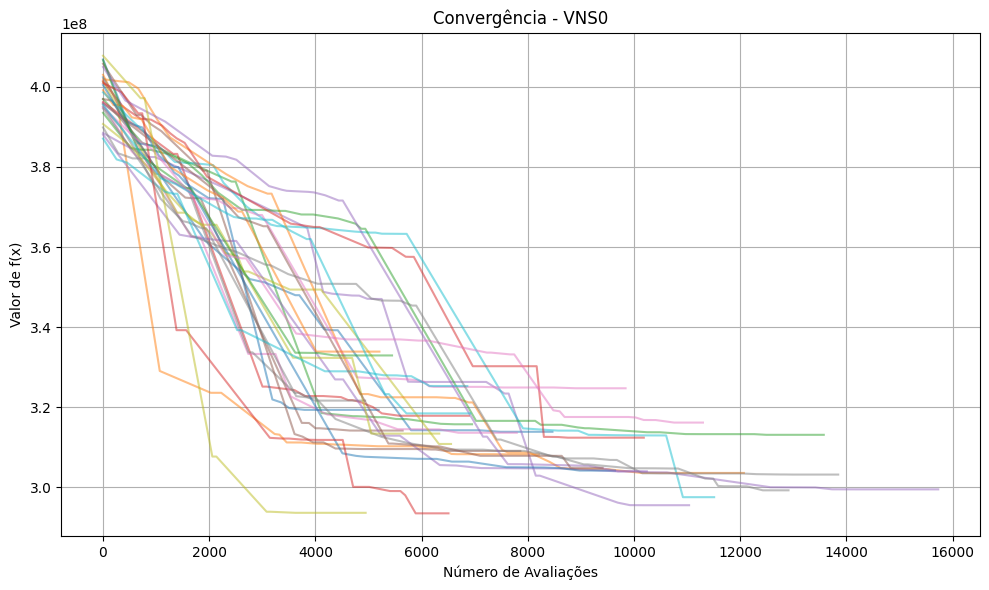

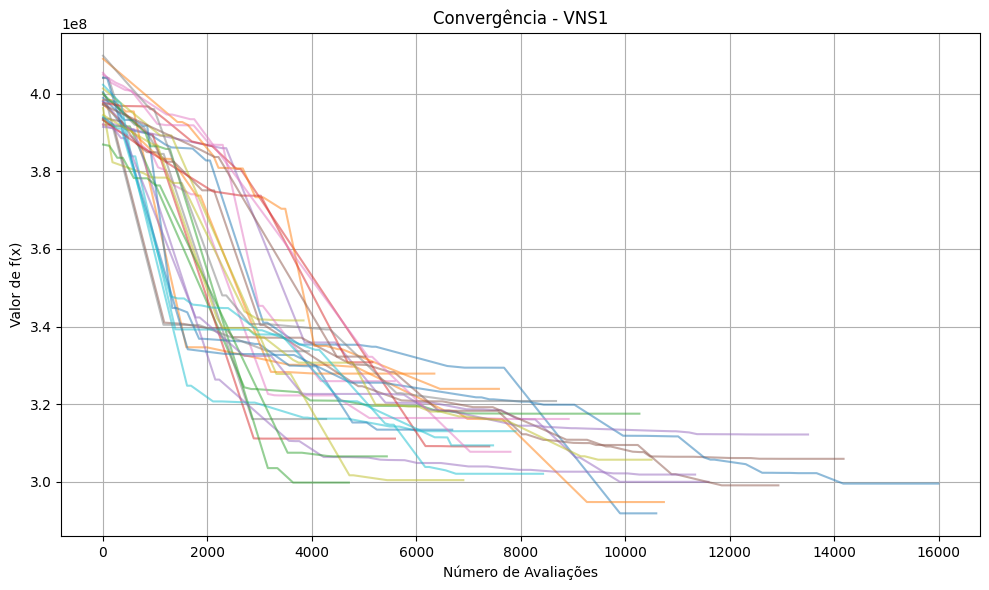

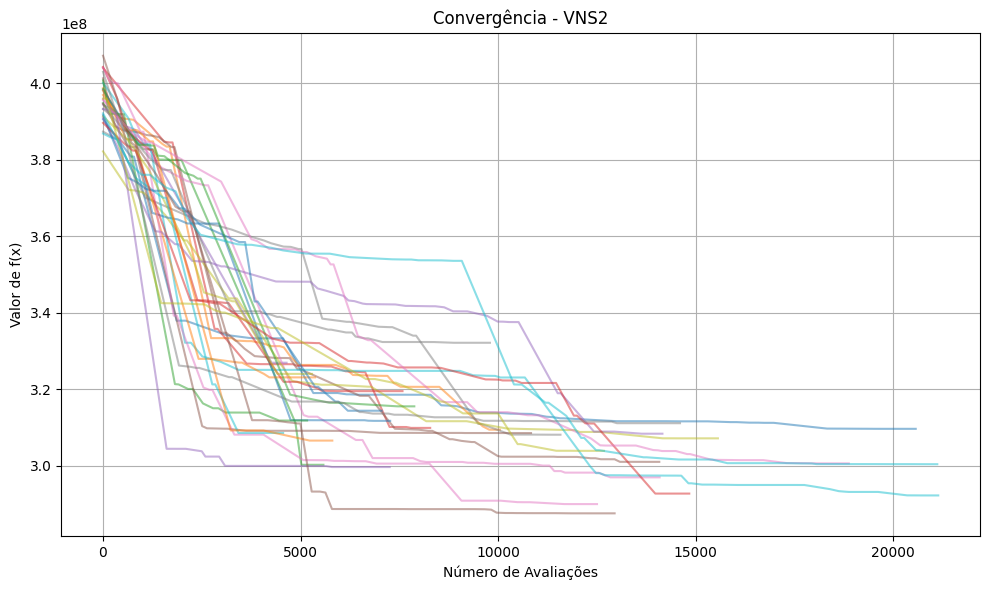

In [5]:
# Plotar uma figura por método
for vns_index, method_replicas in enumerate(solutions):
    plt.figure(figsize=(10, 6))
    plt.title(f'Convergência - {vns_names[vns_index]}')
    plt.xlabel('Número de Avaliações')
    plt.ylabel('Valor de f(x)')

    exec_counter = 0  # Contador de execuções para dar nome às linhas se quiser

    for replica_index, executions in enumerate(method_replicas):
        for execution_index, sol in enumerate(executions):
            try:
                convergence = sol.convergence.get()
                x_vals, y_vals = convergence[0], convergence[1]

                plt.plot(x_vals, y_vals, alpha=0.5, label=f'Execução {exec_counter + 1}')
                exec_counter += 1
            except Exception as e:
                print(f"Erro na VNS{vns_index} - réplica {replica_index} execução {execution_index}: {e}")

    plt.grid(True)
    plt.tight_layout()
    plt.show()

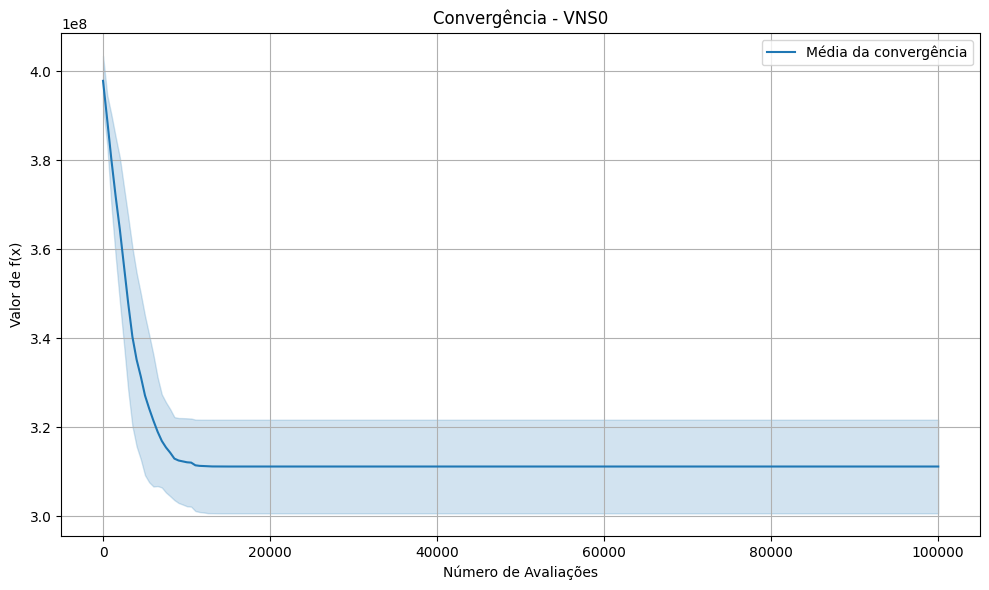

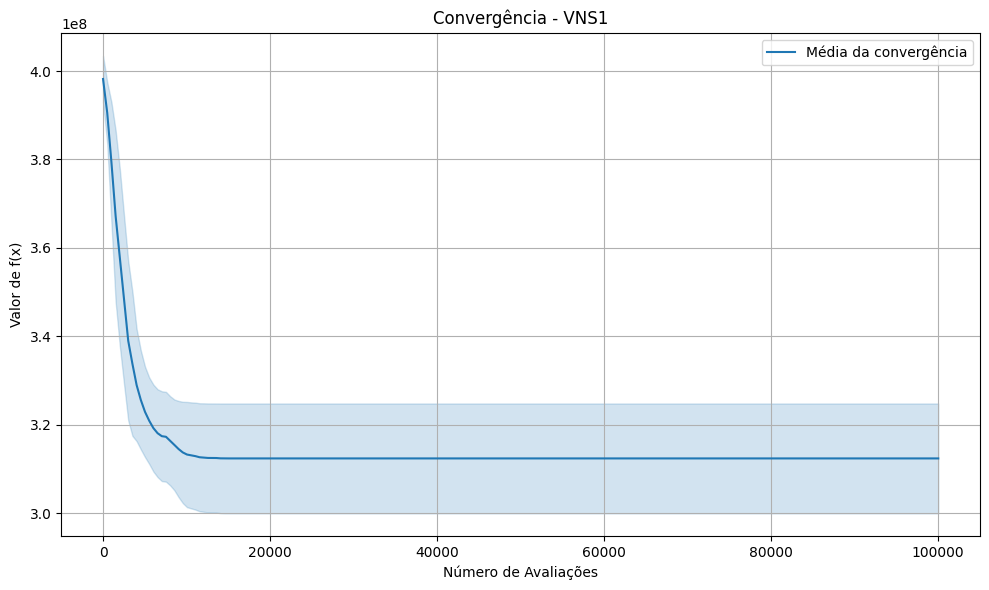

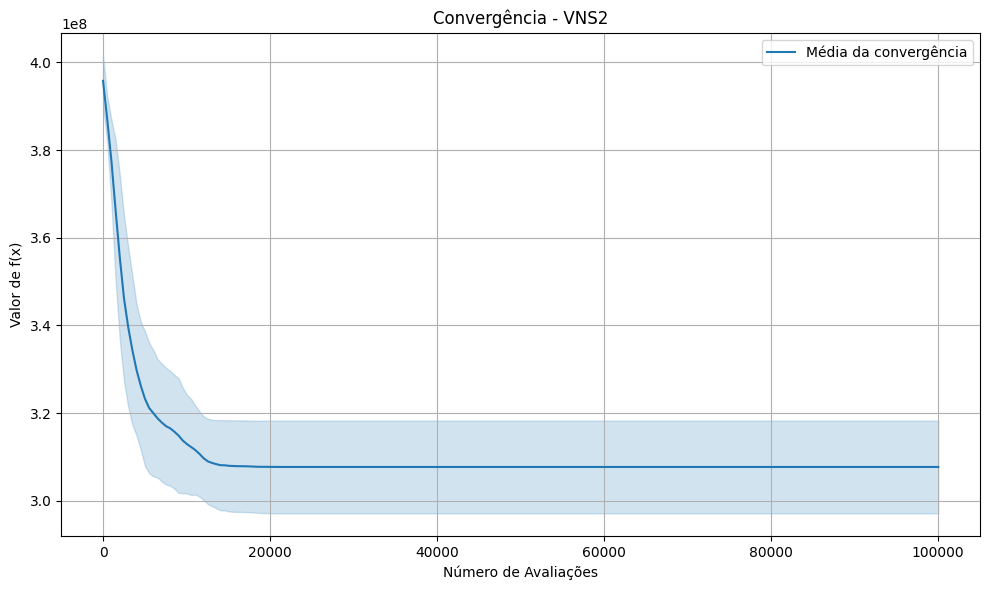

In [ ]:
for vns_index, method_replicas in enumerate(solutions):
    plt.figure(figsize=(10, 6))
    plt.title(f'Convergência - {vns_names[vns_index]}')
    plt.xlabel('Número de Avaliações')
    plt.ylabel('Valor de f(x)')

    # Criamos uma lista para armazenar todas as curvas
    all_convergences = []

    for replica_index, executions in enumerate(method_replicas):
        for execution_index, sol in enumerate(executions):
            try:
                convergence = sol.convergence.get()
                if convergence.shape[1] >= 2:
                    all_convergences.append(convergence)
            except Exception as e:
                print(f"Erro na VNS{vns_index} - réplica {replica_index} execução {execution_index}: {e}")

    # Interpolação para eixo comum
    if all_convergences:
        x_common = np.linspace(0, 100000, 200)
        interpolated_curves = []
        for curve in all_convergences:
            x_vals, y_vals = curve[0], curve[1]
            interpolated = np.interp(x_common, x_vals, y_vals)
            interpolated_curves.append(interpolated)

        mean_curve = np.mean(interpolated_curves, axis=0)
        std_curve = np.std(interpolated_curves, axis=0)

        plt.plot(x_common, mean_curve, label='Média da convergência', color='tab:blue')
        plt.fill_between(x_common, mean_curve - std_curve, mean_curve + std_curve, alpha=0.2, color='tab:blue')

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

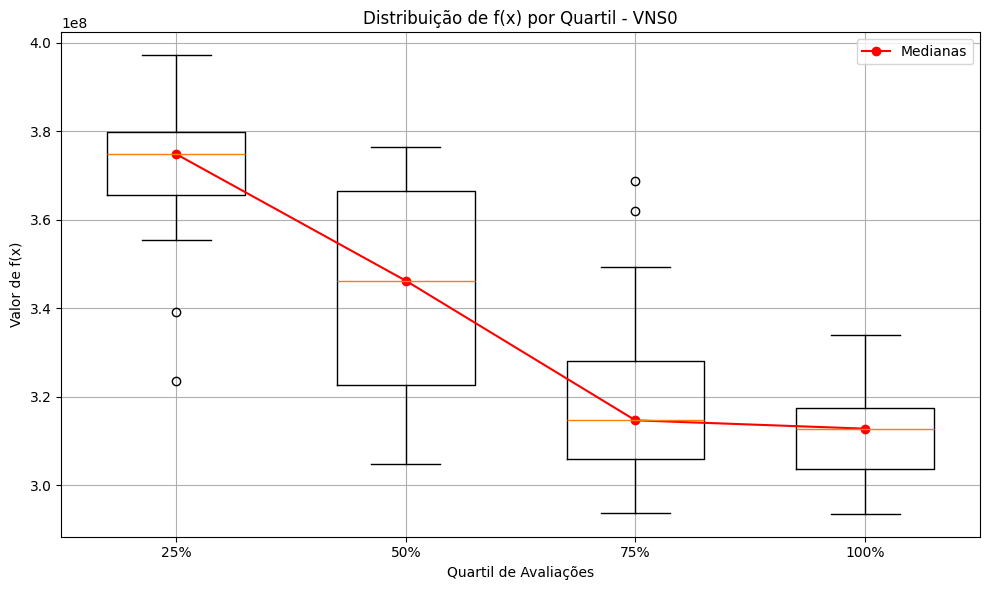

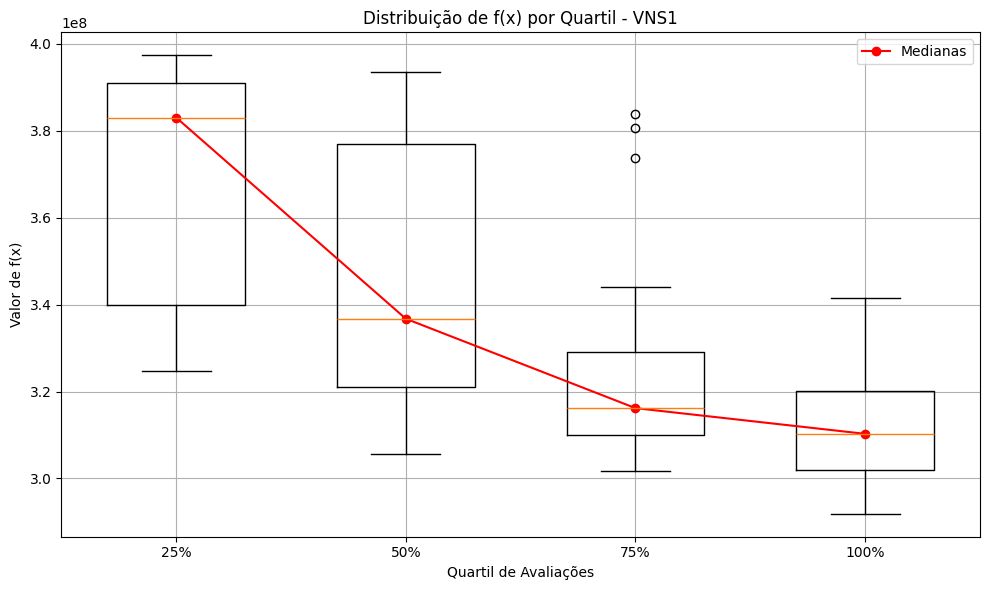

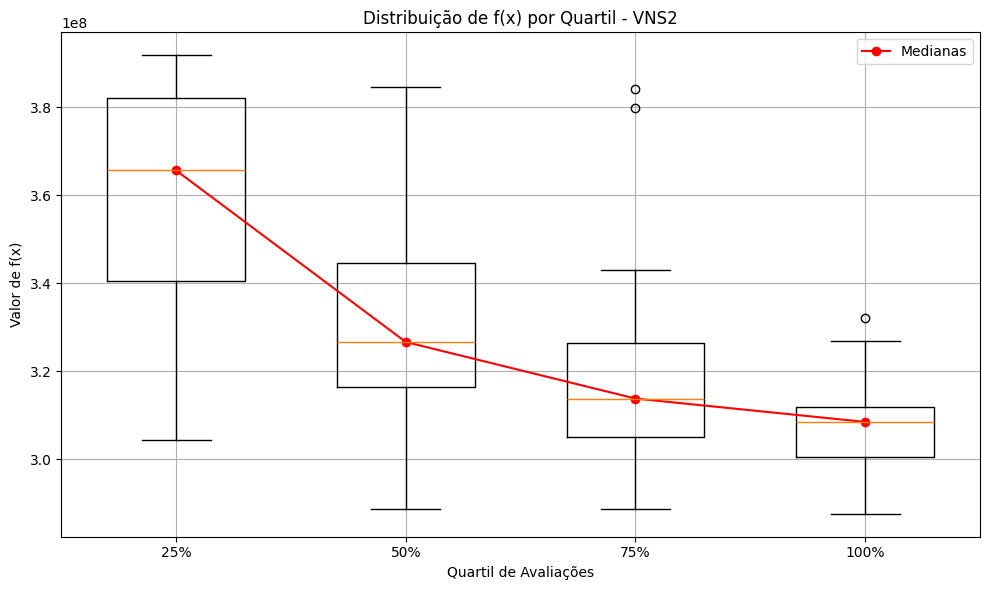

In [8]:
for vns_index, method_replicas in enumerate(solutions):
    all_fx_by_quartile = [[] for _ in range(4)]  # 4 quartis

    for replica_index, executions in enumerate(method_replicas):
        for execution_index, sol in enumerate(executions):
            try:
                convergence = sol.convergence.get()
                num_evals = convergence[0]
                fx_vals = convergence[1]

                # Garantir que os dados estão ordenados por número de avaliações
                sorted_indices = np.argsort(num_evals)
                num_evals = np.array(num_evals)[sorted_indices]
                fx_vals = np.array(fx_vals)[sorted_indices]

                total_evals = num_evals[-1]
                for i, q in enumerate(quartis):
                    eval_point = int(total_evals * q)
                    # Pegar o fx mais próximo do ponto desejado
                    idx = np.searchsorted(num_evals, eval_point, side='right') - 1
                    if idx >= 0 and idx < len(fx_vals):
                        all_fx_by_quartile[i].append(fx_vals[idx])
            except Exception as e:
                print(f"Erro na VNS{vns_index} réplica {replica_index} execução {execution_index}: {e}")

    # Plotar boxplots
    plt.figure(figsize=(10, 6))
    plt.boxplot(all_fx_by_quartile, positions=[1, 2, 3, 4], widths=0.6)
    plt.xticks([1, 2, 3, 4], ['25%', '50%', '75%', '100%'])
    plt.xlabel('Quartil de Avaliações')
    plt.ylabel('Valor de f(x)')
    plt.title(f'Distribuição de f(x) por Quartil - {vns_names[vns_index]}')

    # Adicionar linha ligando as medianas
    medians = [np.median(q) for q in all_fx_by_quartile]
    plt.plot([1, 2, 3, 4], medians, marker='o', linestyle='-', color='red', label='Medianas')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    
    plt.show()